## SARIMAX

**Objetivo:** desenvolver um modelo de previsão de PM2.5 utilizando SARIMAX, incorporando variáveis meteorológicas e sazonalidades temporais para previsão das próximas 24 horas.

- Avaliando ciclos sazonais e correlação entre variáveis
- VIF (variáveis atmosféricas)
- Estacionaridade

In [1]:
%matplotlib widget

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

### 1. Carregamento dos dados

In [3]:
# abrindo base de dados para treinamento - testando inicialmente com a série original com gaps
data = pd.read_csv("../data/data_sem_interpolacao/dados_pm25_umi_temp_2016_2019_nan.csv")
data.head()

,time,MP2.5,temperature_2m,relative_humidity_2m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490


In [4]:
data["time"] = pd.to_datetime(data["time"])
data = data.set_index("time").sort_index()

data.head()

,MP2.5,temperature_2m,relative_humidity_2m
time,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490


### 2. Exploração da Série Temporal (Ciclos)

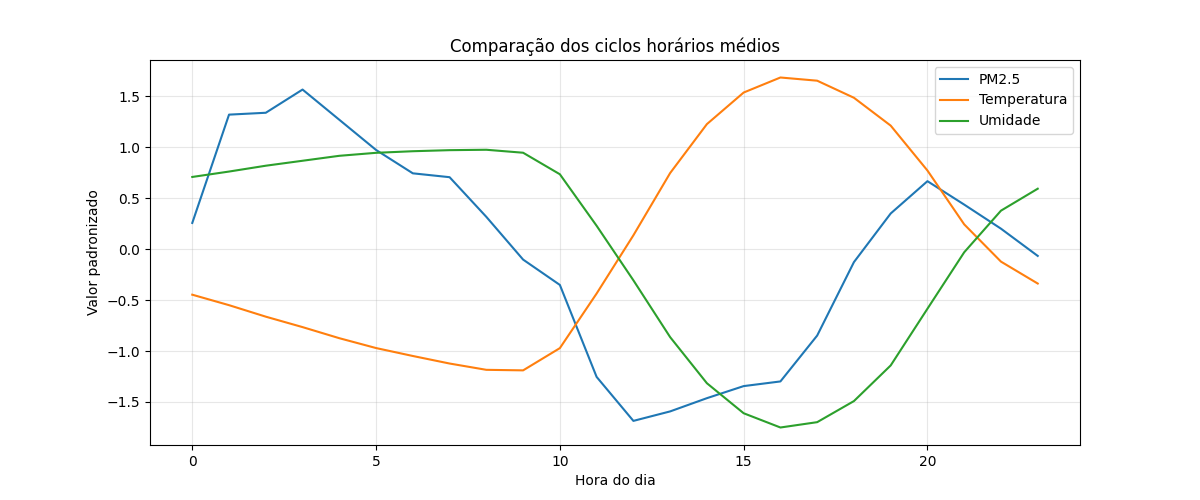

In [5]:
#ciclo diário
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.hour)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.hour)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.hour)["relative_humidity_2m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos horários médios")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.show()

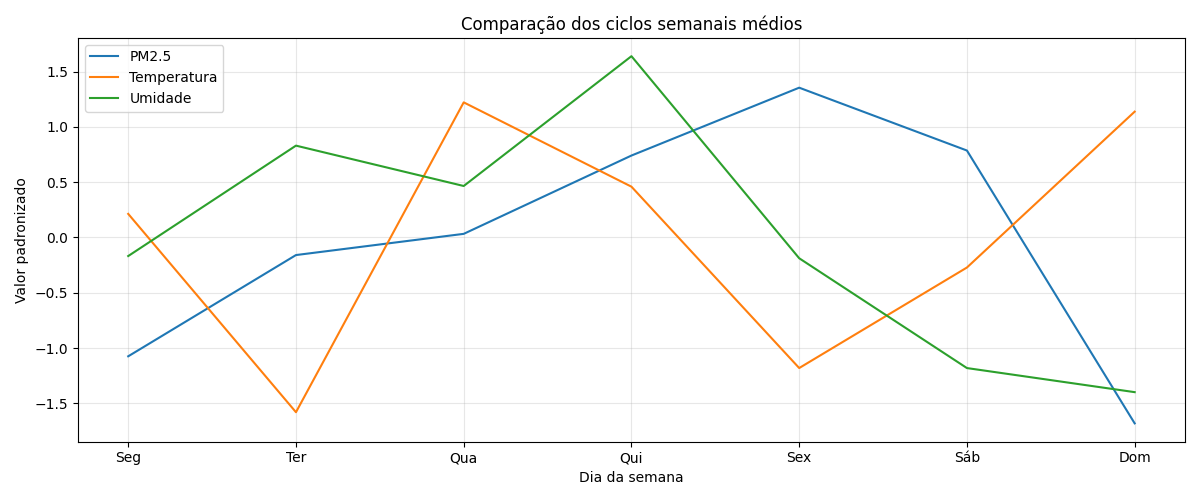

In [6]:
# ciclo semanal
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.dayofweek)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.dayofweek)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.dayofweek)["relative_humidity_2m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
ciclo_norm.index = dias

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos semanais médios")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

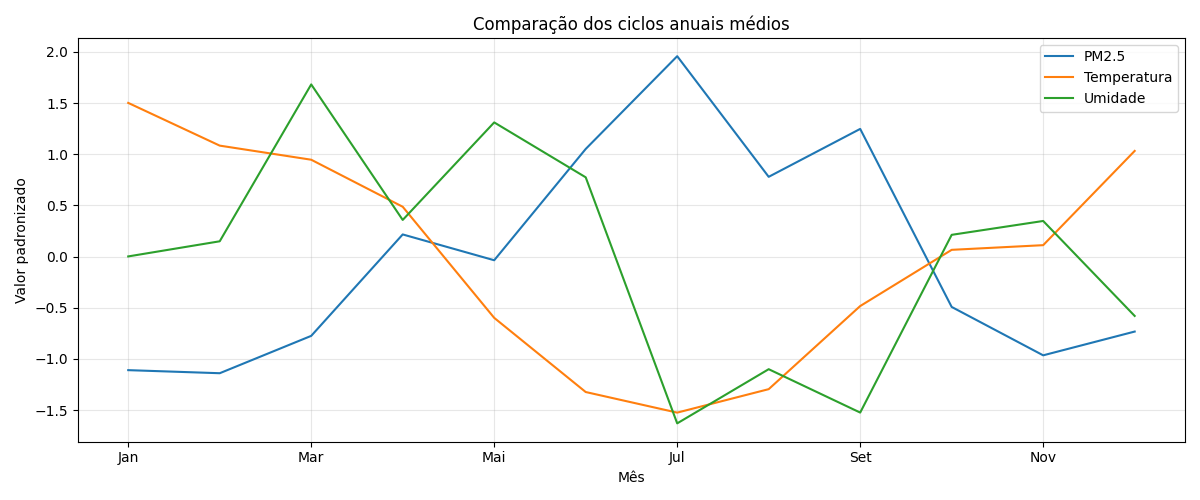

In [7]:
# ciclo anual
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.month)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.month)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.month)["relative_humidity_2m"].mean()
})


ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

meses = [
    "Jan", "Fev", "Mar", "Abr",
    "Mai", "Jun", "Jul", "Ago",
    "Set", "Out", "Nov", "Dez"
]

ciclo_norm.index = meses

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos anuais médios")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Correlação entre variáveis

In [8]:
######### Temperatura e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_temp = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["temperature_2m"].shift(lag)
    )

    corr_temp.append(c)

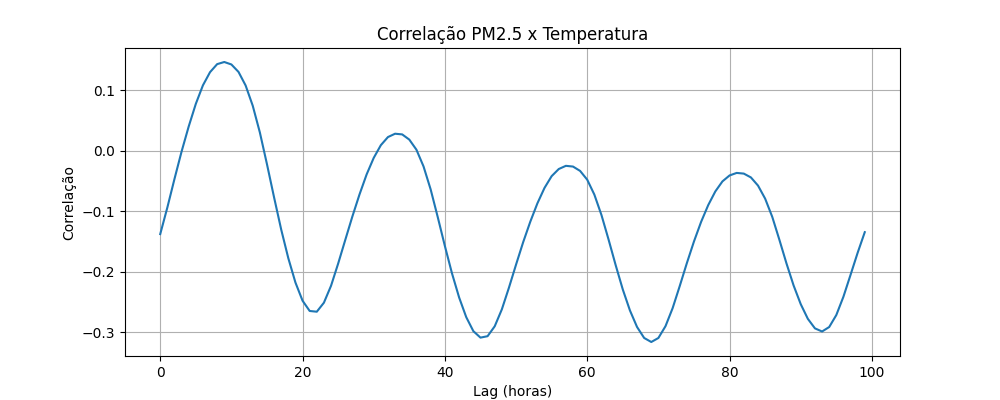

In [9]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Temperatura")
plt.grid()

plt.show()

In [10]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi.append(c)

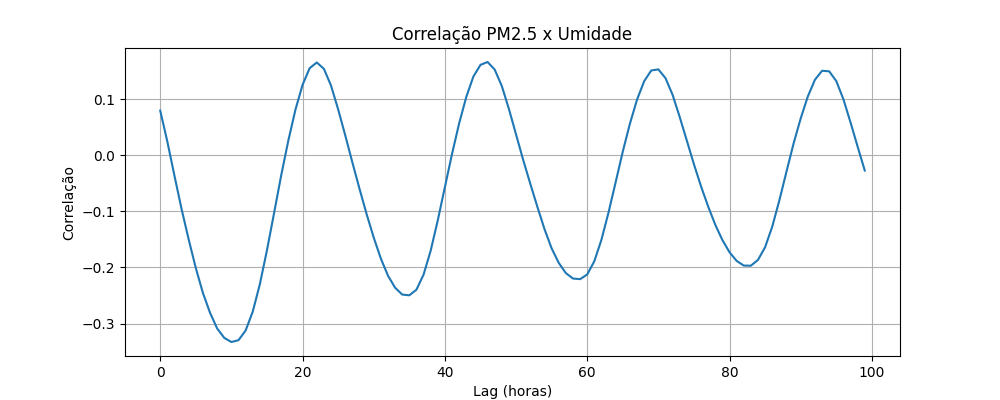

In [11]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Umidade")
plt.grid()

plt.show()

In [12]:
corr_pm25 = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["MP2.5"].shift(lag)
    )

    corr_pm25.append(c)

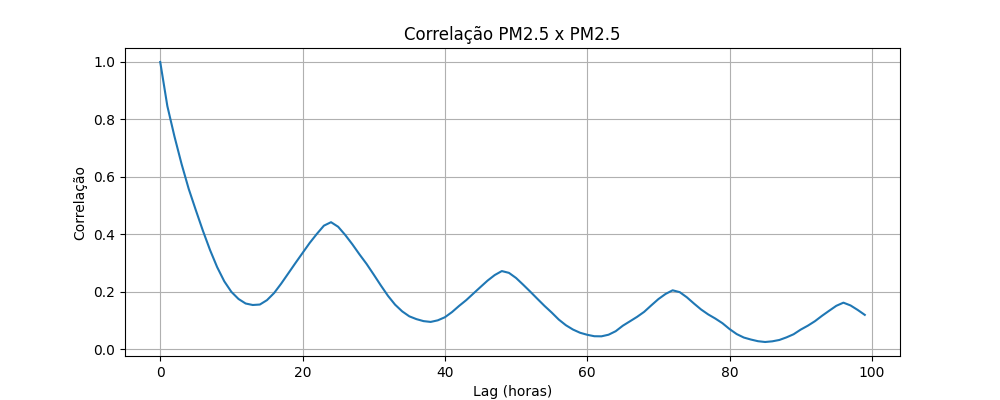

In [13]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_pm25)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x PM2.5")
plt.grid()

plt.show()

In [14]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi_temp = []

for lag in range(0, 100):

    c = data["temperature_2m"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi_temp.append(c)

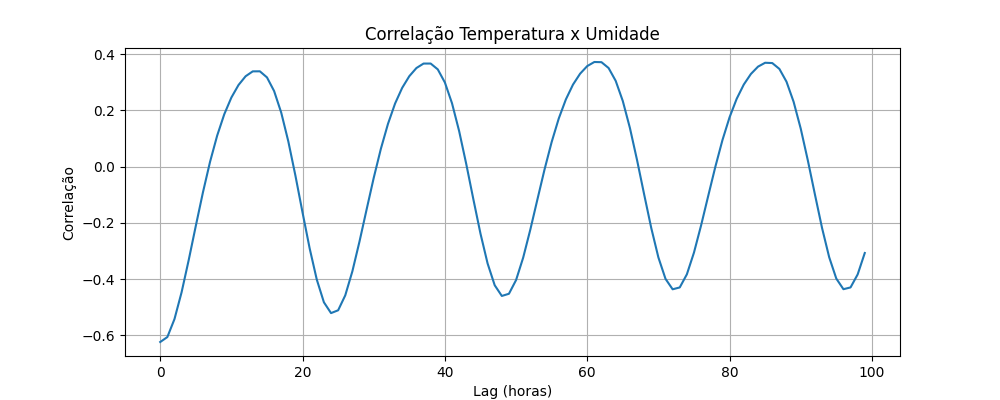

In [15]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação Temperatura x Umidade")
plt.grid()

plt.show()

### 4. VIF (Variance Inflation Factor): Investigando multicolinearidade entre as features

In [16]:
# normalizando utilizando StandardScaler()
cols = [
    "temperature_2m",
    "relative_humidity_2m"
]

scaler = StandardScaler()

data_scaled = data.drop(columns=["MP2.5"]).copy()
#data_scaled = data.copy()

data_scaled[cols] = scaler.fit_transform(
    data_scaled[cols]
)

data_scaled.head()

,temperature_2m,relative_humidity_2m
time,,
2016-03-01 00:00:00+00:00,-0.303972,0.807668
2016-03-01 01:00:00+00:00,-0.292856,0.867885
2016-03-01 02:00:00+00:00,-0.281741,0.827881
2016-03-01 03:00:00+00:00,-0.303972,0.887937
2016-03-01 04:00:00+00:00,-0.292856,0.867885


In [17]:
#Considerar VIF ≥  10 como um potencial problema

df = pd.DataFrame()

df["features"] = data_scaled.columns

df["vif_index"] = [vif(data_scaled.values, i) for i in range(data_scaled.shape[1])]

round(df.sort_values(by="vif_index", ascending = False),2)

,features,vif_index
0,temperature_2m,1.64
1,relative_humidity_2m,1.64


### 5. Entendendo estacionaridade e defasegem de PM2.5

In [18]:
# Avaliando período máximo contínuo sem gaps temporais para análise.
# Tentei fazer a análise com a série completa mas como tem gaps quis comparar também com uma série contínua
# para ter certeza que os gaps não estavam influenciando as estimativas, principalmente da estacionaridade.

def encontrar_segmentos_continuos(df, col="MP2.5", freq="h"):
    serie = df[col].copy()

    serie = serie.sort_index().asfreq(freq)

    valido = serie.notna()

    grupo = (valido != valido.shift()).cumsum()

    segmentos = []

    for _, bloco in serie.groupby(grupo):
        if bloco.notna().all():
            segmentos.append({
                "inicio": bloco.index[0],
                "fim": bloco.index[-1],
                "n_horas": len(bloco),
                "n_dias": len(bloco) / 24
            })

    segmentos = pd.DataFrame(segmentos)

    if segmentos.empty:
        return segmentos

    return segmentos.sort_values("n_horas", ascending=False).reset_index(drop=True)

In [19]:
segmentos = encontrar_segmentos_continuos(data, col="MP2.5", freq="h")
segmentos.head(10)

,inicio,fim,n_horas,n_dias
0,2016-11-08 18:00:00+00:00,2017-03-31 05:00:00+00:00,3420,142.500000
1,2019-03-05 17:00:00+00:00,2019-05-30 11:00:00+00:00,2059,85.791667
2,2018-12-26 15:00:00+00:00,2019-03-05 14:00:00+00:00,1656,69.000000
3,2017-11-07 14:00:00+00:00,2018-01-14 19:00:00+00:00,1638,68.250000
4,2017-05-04 17:00:00+00:00,2017-07-10 12:00:00+00:00,1604,66.833333
5,2018-04-05 12:00:00+00:00,2018-06-04 22:00:00+00:00,1451,60.458333
6,2018-01-17 03:00:00+00:00,2018-03-14 22:00:00+00:00,1364,56.833333
7,2016-07-17 12:00:00+00:00,2016-08-31 10:00:00+00:00,1079,44.958333
8,2016-05-01 16:00:00+00:00,2016-06-10 02:00:00+00:00,947,39.458333
9,2018-06-19 03:00:00+00:00,2018-07-24 19:00:00+00:00,857,35.708333


In [20]:
maior = segmentos.iloc[0]

inicio = maior["inicio"]
fim = maior["fim"]

data_continua = data.loc[inicio:fim].copy()

print(inicio, fim)
print(f"{maior['n_dias']:.1f} dias contínuos")

2016-11-08 18:00:00+00:00 2017-03-31 05:00:00+00:00
142.5 dias contínuos


In [21]:
# Avaliando impactos diretos e indiretos de PM2.5
def plot_autocorrelation(y, d=0, D=0, m=0):
    y = pd.Series(y)
    if D > 0:
        for i in range(D):
            y = y.diff(m)
    if d > 0:
        for i in range(d):
            y = y.diff(1)
    fig = plt.figure(figsize=(20,10))
    ax1 = fig.add_subplot(2,1,1)
    ax2 = fig.add_subplot(2,2,3)
    ax3 = fig.add_subplot(2,2,4)
    ax1.plot(y)
    plot_acf(y, lags = 50, ax=ax2);
    plot_pacf(y, lags=50, method='ywm', ax=ax3, color='r');
    plt.show()

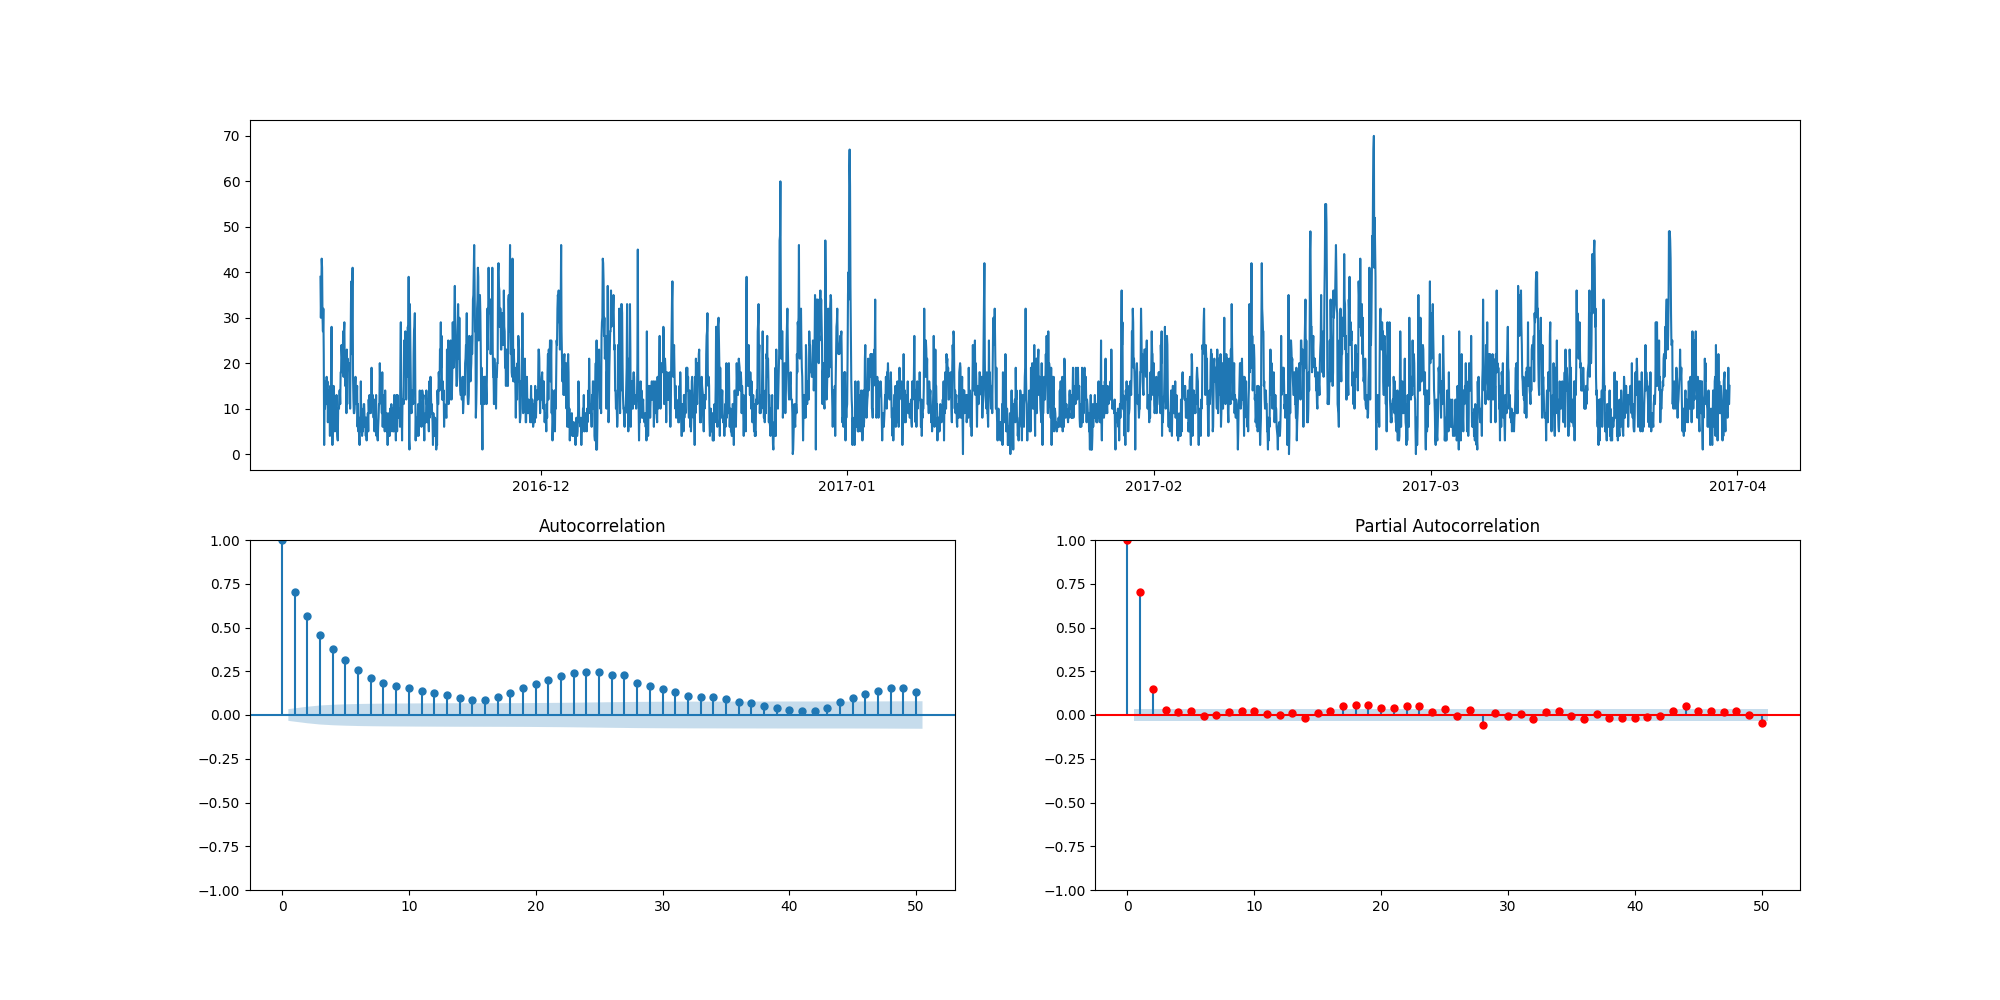

In [22]:
plot_autocorrelation(data_continua["MP2.5"], d=0, D=0, m=24)

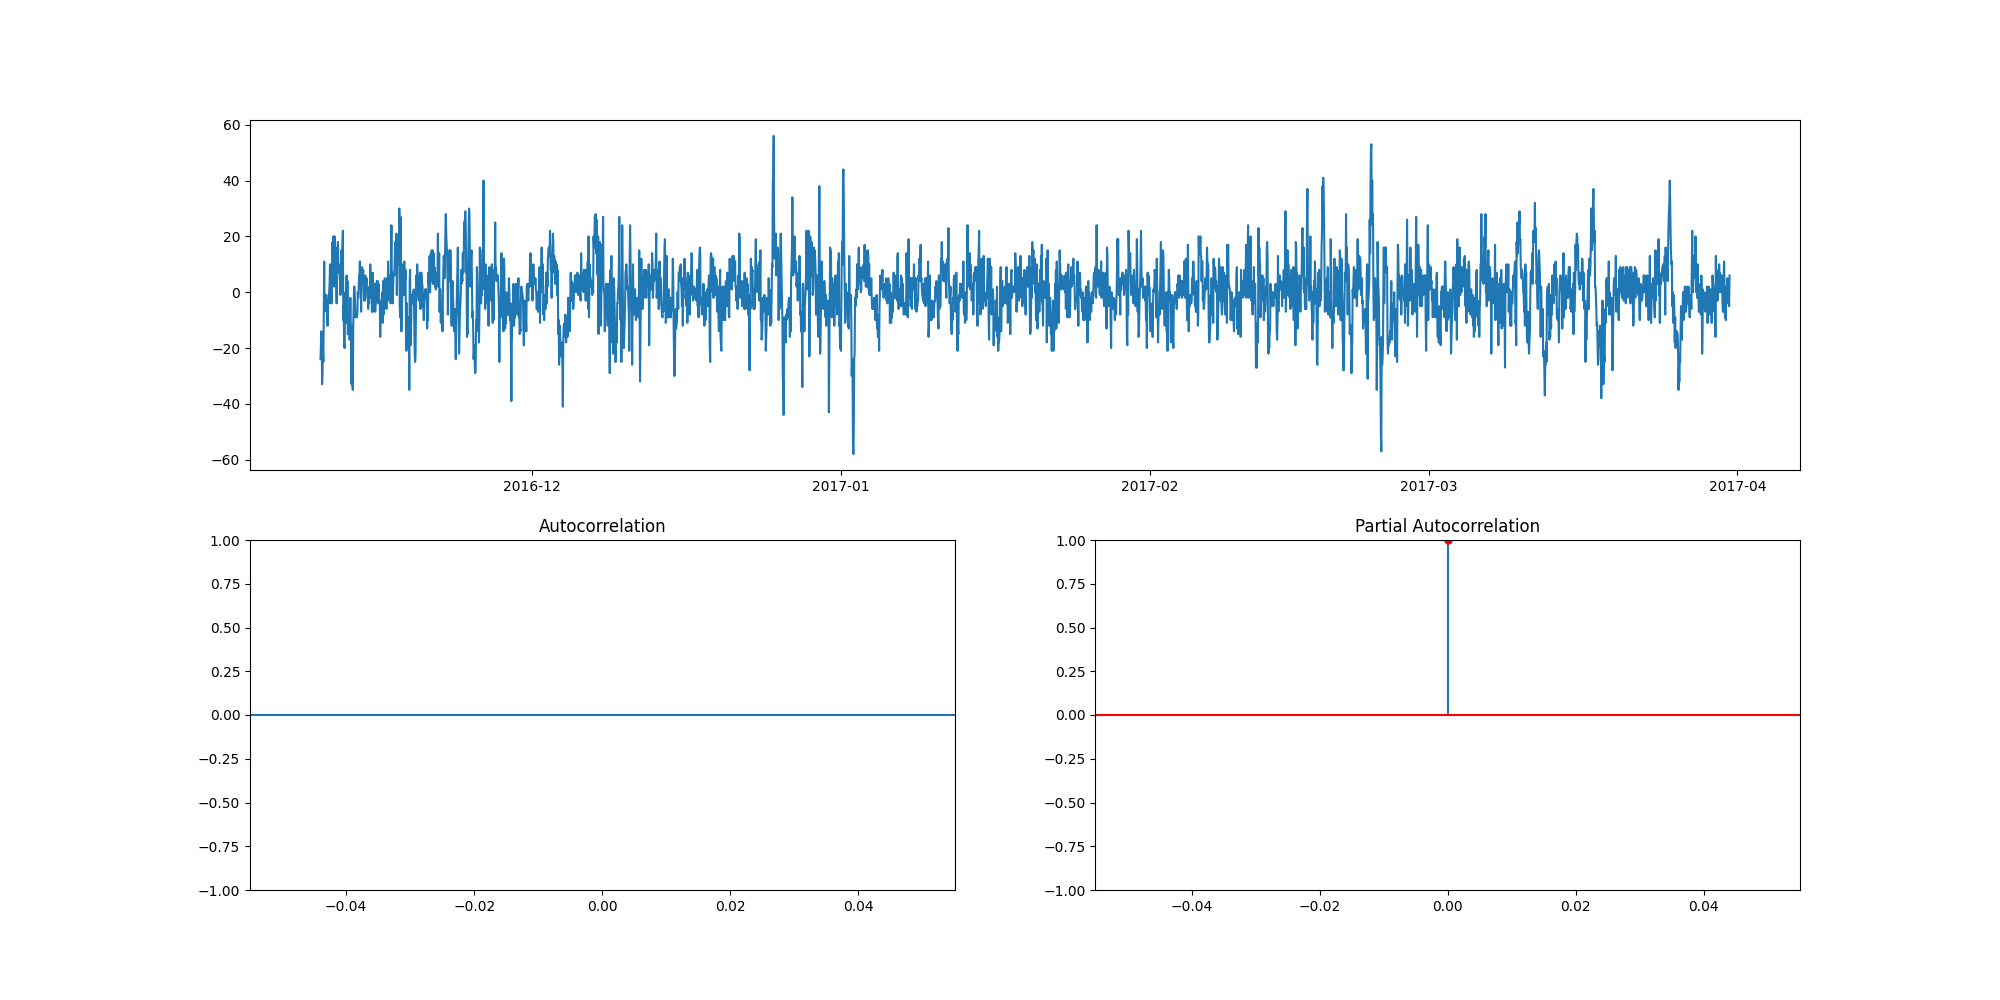

In [23]:
plot_autocorrelation(data_continua["MP2.5"],d=0,D=1,m=24)

Avaliando a Estacionaridade

**************
O p-valor deve ser menor que 0,05 para que possamos ter 95% de confiança de que a série é estacionária.

Idealmente, o p-valor deve ser muito menor que 0,05.
*************
seasonal_order=(P,1,Q,24)

In [24]:
result = adfuller(data_continua["MP2.5"])

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -6.677629191689672
p-value: 4.423892863798992e-09


### 6. Separando conjunto de treino e teste

In [48]:
## cortando a série para teste pq o treino travou
metade = int(len(data) * 0.3)
data_50 = data.iloc[:metade]

### separando em teste e treino 70% para treino e 30% para teste
train_size = 0.7

index = round(train_size*data_50.shape[0])
df_train = data_50.iloc[:index]
df_test = data_50.iloc[index+1:]

y = data_50["MP2.5"]
y_train = df_train["MP2.5"]
y_test = df_test["MP2.5"]

# testando inicialmente somente com temperatura como exogena
exog = data_50['temperature_2m']
exog_train = df_train['temperature_2m']
exog_test = df_test['temperature_2m']

In [49]:
from dateutil.relativedelta import relativedelta

print(f'Intevalo de treino: {y_train.index[0]} a {y_train.index[-1]}')
diff = relativedelta(y_train.index[-1], y_train.index[0])
print(diff)

print(f'Intevalo de teste: {y_test.index[0]} a {y_test.index[0]}')
diff = relativedelta(y_test.index[-1], y_test.index[0])
print(diff)

Intevalo de treino: 2016-03-01 00:00:00+00:00 a 2016-11-21 15:00:00+00:00
relativedelta(months=+8, days=+20, hours=+15)
Intevalo de teste: 2016-11-21 17:00:00+00:00 a 2016-11-21 17:00:00+00:00
relativedelta(months=+3, days=+21, hours=+18)


### 7. Modelagem

In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# p=2 (PACF), d=0 (estacionaria), q=1 (ACF), m=24 (ciclo diário é o meu forte)

model = SARIMAX(
    y_train,
    order=(2,0,1),
    seasonal_order=(2,0,1,24)
)

/home/izabel/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/izabel/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [ ]:
results = model.fit()